# Exploratory Data Analysis: Airline Passenger Satisfaction

**Dataset**: Airline Passenger Satisfaction  
**Objective**: Understand what factors influence passenger satisfaction and prepare data for predictive modeling

In [22]:
# Import libraries and set up the environment
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')
np.random.seed(42)

# Set working directory to project root
while not os.path.exists('requirements.txt') and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir('..')

# Create main directory for analysis reports
reports_dir = "reports/eda"
os.makedirs(reports_dir, exist_ok=True)

# Create organized subdirectories for different file types
html_reports_dir = os.path.join(reports_dir, "interactive_visualizations")
png_reports_dir = os.path.join(reports_dir, "static_images")
csv_reports_dir = os.path.join(reports_dir, "data_exports")
json_reports_dir = os.path.join(reports_dir, "configuration")

# Create all subdirectories
for directory in [html_reports_dir, png_reports_dir, csv_reports_dir, json_reports_dir]:
    os.makedirs(directory, exist_ok=True)

print(f"Working directory: {os.getcwd()}")
print(f"Analysis report directory: {reports_dir}")
print(f"Organized subdirectories created:")
print(f"   - interactive_visualizations/  (HTML reports)")
print(f"   - static_images/               (PNG charts)")
print(f"   - data_exports/                (CSV files)")
print(f"   - configuration/               (JSON files)")

Working directory: c:\Users\finle\Git_projects\ML_Assingnment_2
Analysis report directory: reports/eda
Organized subdirectories created:
   - interactive_visualizations/  (HTML reports)
   - static_images/               (PNG charts)
   - data_exports/                (CSV files)
   - configuration/               (JSON files)


## 1. Setting Up the Analysis

In [23]:
# Load the dataset
df = pd.read_csv("dataset/test_original.csv")
df_original = df.copy()

print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nShape: {df.shape[0]:,} records × {df.shape[1]} features")
print(f"\nColumn information:")
print(df.dtypes)
print(f"\nFirst few records:")
df.head()


DATASET OVERVIEW

Shape: 98,904 records × 25 features

Column information:
Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service        

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 2. Loading and Exploring the Data

In [24]:
# Check data quality
print("\n" + "="*60)
print("DATA QUALITY CHECK")
print("="*60)

# Check for missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
if missing_data.sum() == 0:
    print("\nNo missing values detected")
else:
    print(f"\nMissing values:")
    print(pd.DataFrame({'Count': missing_data[missing_data > 0], 
                        'Percentage': missing_percent[missing_data > 0]}))

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Memory usage
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory usage: {memory_mb:.2f} MB")

# Basic statistics
print(f"\nBasic statistics:")
print(df.describe())


DATA QUALITY CHECK

Missing values:
                          Count  Percentage
Arrival Delay in Minutes    299    0.302313
Duplicate rows: 0
Memory usage: 43.60 MB

Basic statistics:
          Unnamed: 0             id           Age  Flight Distance  \
count   98904.000000   98904.000000  98904.000000     98904.000000   
mean    52003.363464   64980.800524     39.371805      1189.646324   
std     30001.153118   37454.398194     15.114978       997.154483   
min         0.000000       1.000000      7.000000        31.000000   
25%     25987.750000   32590.750000     27.000000       414.000000   
50%     52026.500000   64970.500000     40.000000       842.000000   
75%     78020.250000   97428.250000     51.000000      1744.000000   
max    103903.000000  129880.000000     85.000000      4983.000000   

       Inflight wifi service  Departure/Arrival time convenient  \
count           98904.000000                       98904.000000   
mean                2.730719                      

In [25]:
# Analyze the target variable - Satisfaction
print("\n" + "="*60)
print("TARGET VARIABLE ANALYSIS")
print("="*60)

satisfaction_counts = df['satisfaction'].value_counts()
print(f"\nSatisfaction distribution:")
print(satisfaction_counts)
print(f"\nPercentages:")
print(df['satisfaction'].value_counts(normalize=True).round(4) * 100)

#Visualization
fig_satisfaction = px.bar(
    satisfaction_counts,
    x=satisfaction_counts.index,
    y=satisfaction_counts.values,
    labels={'x': 'Satisfaction Level', 'y': 'Number of Passengers'},
    title='Passenger Satisfaction Distribution',
    color=satisfaction_counts.index,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig_satisfaction.update_layout(height=500, showlegend=False)
fig_satisfaction.write_html(f"{html_reports_dir}/01_satisfaction_distribution.html")


TARGET VARIABLE ANALYSIS

Satisfaction distribution:
satisfaction
neutral or dissatisfied    56083
satisfied                  42821
Name: count, dtype: int64

Percentages:
satisfaction
neutral or dissatisfied    56.7
satisfied                  43.3
Name: proportion, dtype: float64


In [26]:
# ============================================
# 4. CATEGORICAL VARIABLES ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("CATEGORICAL VARIABLES ANALYSIS")
print("=" * 60)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical Columns: {categorical_cols}")

# Create detailed analysis for categorical variables
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Unique Values: {df[col].nunique()}")

# Create categorical distributions - Plotly subplots
categorical_cols_viz = [col for col in categorical_cols if col != 'satisfaction']

fig_categorical = make_subplots(
    rows=2, cols=2,
    subplot_titles=categorical_cols_viz,
    specs=[[{"type": "bar"}, {"type": "bar"}], [{"type": "bar"}, {"type": "bar"}]]
)

for idx, col in enumerate(categorical_cols_viz):
    row = idx // 2 + 1
    col_pos = idx % 2 + 1
    value_counts = df[col].value_counts()
    
    fig_categorical.add_trace(
        go.Bar(x=value_counts.index, y=value_counts.values, 
               name=col, marker=dict(opacity=0.7)),
        row=row, col=col_pos
    )

fig_categorical.update_layout(
    height=700,
    title_text="Categorical Variables Distribution",
    showlegend=False,
    hovermode='x unified'
)
fig_categorical.write_html(f"{html_reports_dir}/02_categorical_distributions.html")


CATEGORICAL VARIABLES ANALYSIS

Categorical Columns: ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

Gender:
Gender
Female    50215
Male      48689
Name: count, dtype: int64
Unique Values: 2

Customer Type:
Customer Type
Loyal Customer       80814
disloyal Customer    18090
Name: count, dtype: int64
Unique Values: 2

Type of Travel:
Type of Travel
Business travel    68203
Personal Travel    30701
Name: count, dtype: int64
Unique Values: 2

Class:
Class
Business    47293
Eco         44490
Eco Plus     7121
Name: count, dtype: int64
Unique Values: 3

satisfaction:
satisfaction
neutral or dissatisfied    56083
satisfied                  42821
Name: count, dtype: int64
Unique Values: 2


## 3. Univariate Analysis

In [27]:
# ============================================
# 5. NUMERICAL VARIABLES ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("NUMERICAL VARIABLES ANALYSIS")
print("=" * 60)

# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['id', 'Unnamed: 0']]
print(f"\nNumerical Columns: {numerical_cols}")

# Create histograms for key numerical features
key_numerical = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 
                 'Arrival Delay in Minutes']

fig_distributions = make_subplots(
    rows=2, cols=2,
    subplot_titles=key_numerical,
    specs=[[{"secondary_y": False}, {"secondary_y": False}], 
           [{"secondary_y": False}, {"secondary_y": False}]]
)

for idx, col in enumerate(key_numerical):
    if col in df.columns:
        row = idx // 2 + 1
        col_pos = idx % 2 + 1
        
        fig_distributions.add_trace(
            go.Histogram(x=df[col], name=col, nbinsx=30, opacity=0.7),
            row=row, col=col_pos,
            secondary_y=False
        )

fig_distributions.update_layout(
    height=700,
    title_text="Distribution of Key Numerical Features",
    showlegend=False,
    hovermode='x unified'
)
fig_distributions.update_xaxes(title_text="Value")
fig_distributions.update_yaxes(title_text="Frequency")
fig_distributions.write_html(f"{html_reports_dir}/03_numerical_distributions.html")


NUMERICAL VARIABLES ANALYSIS

Numerical Columns: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [28]:
# ============================================
# 6. CORRELATION ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Create correlation matrix for numerical features
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Create heatmap - Plotly
fig_corr = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmid=0,
    text=np.round(corr_matrix.values, 2),
    texttemplate='%{text:.2f}',
    textfont={"size": 8},
    hovertemplate='%{y} vs %{x}: %{z:.3f}<extra></extra>'
))

fig_corr.update_layout(
    title='Correlation Matrix Heatmap',
    height=800,
    width=900,
    xaxis_title='Features',
    yaxis_title='Features'
)
fig_corr.write_html(f"{html_reports_dir}/04_correlation_matrix.html")

# Convert satisfaction to numeric for correlation with target
df_temp = df.copy()
df_temp['satisfaction_numeric'] = (df_temp['satisfaction'] == 'satisfied').astype(int)

# Top correlations with target
print("\nTop Features Correlated with Satisfaction (numerical):")
numeric_df_with_target = df_temp.select_dtypes(include=[np.number])
satisfaction_target = numeric_df_with_target.corr()['satisfaction_numeric'].sort_values(ascending=False)
print(satisfaction_target)


CORRELATION ANALYSIS

Top Features Correlated with Satisfaction (numerical):
satisfaction_numeric                 1.000000
Online boarding                      0.504698
Inflight entertainment               0.397715
Seat comfort                         0.349950
On-board service                     0.322706
Leg room service                     0.314162
Cleanliness                          0.305080
Flight Distance                      0.299338
Inflight wifi service                0.285087
Baggage handling                     0.247440
Inflight service                     0.244946
Checkin service                      0.236478
Food and drink                       0.209752
Ease of Online booking               0.172263
Age                                  0.137453
id                                   0.013868
Gate location                        0.001356
Unnamed: 0                          -0.005404
Departure/Arrival time convenient   -0.050670
Departure Delay in Minutes          -0.050874
Ar

## 4. Feature Relationships

In [29]:
# ============================================
# 7. CATEGORICAL vs TARGET ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("CATEGORICAL FEATURES vs SATISFACTION")
print("=" * 60)

# Create visualizations for categorical vs target
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

for col in cat_cols:
    if col in df.columns:
        # Cross tabulation
        cross_tab = pd.crosstab(df[col], df['satisfaction'])
        print(f"\n{col} vs Satisfaction:\n{cross_tab}")
        
        # Plotly grouped bar chart
        fig_cat_target = px.bar(
            df,
            x=col,
            color='satisfaction',
            barmode='group',
            title=f'Satisfaction by {col}',
            labels={col: col, 'count': 'Count'},
            color_discrete_sequence=px.colors.qualitative.Set2
        )
        fig_cat_target.update_layout(height=500, hovermode='x unified')
        
        filename = f"{html_reports_dir}/05_{col.lower().replace(' ', '_')}_vs_satisfaction.html"
        fig_cat_target.write_html(filename)


CATEGORICAL FEATURES vs SATISFACTION

Gender vs Satisfaction:
satisfaction  neutral or dissatisfied  satisfied
Gender                                          
Female                          28761      21454
Male                            27322      21367

Customer Type vs Satisfaction:
satisfaction       neutral or dissatisfied  satisfied
Customer Type                                        
Loyal Customer                       42269      38545
disloyal Customer                    13814       4276

Type of Travel vs Satisfaction:
satisfaction     neutral or dissatisfied  satisfied
Type of Travel                                     
Business travel                    28493      39710
Personal Travel                    27590       3111

Class vs Satisfaction:
satisfaction  neutral or dissatisfied  satisfied
Class                                           
Business                        14456      32837
Eco                             36253       8237
Eco Plus                        

In [30]:
# ============================================
# 8. NUMERICAL FEATURES vs TARGET ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("NUMERICAL FEATURES vs SATISFACTION")
print("=" * 60)

key_numerical_analysis = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 
                         'Arrival Delay in Minutes']
print(f"\nKey Numerical Features for Target Analysis: {key_numerical_analysis}")

for col in key_numerical_analysis:
    if col in df.columns:
        # Boxplot
        fig_box = px.box(
            df,
            x='satisfaction',
            y=col,
            title=f'{col} by Satisfaction Level',
            color='satisfaction',
            color_discrete_sequence=px.colors.qualitative.Set2
        )
        fig_box.update_layout(height=500, showlegend=False)
        
        filename = f"{html_reports_dir}/06_{col.lower().replace(' ', '_')}_vs_satisfaction.html"
        fig_box.write_html(filename)

# Service quality features analysis
print("\n" + "=" * 60)
print("SERVICE QUALITY FEATURES ANALYSIS")
print("=" * 60)

service_cols = [
    'Inflight wifi service', 'Seat comfort', 'Online boarding',
    'Inflight entertainment', 'On-board service', 'Leg room service',
    'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness'
]

# Filter only columns that exist in dataset
service_cols = [col for col in service_cols if col in df.columns]
print(f"\nService Quality Columns: {service_cols}")

# Create a combined visualization for service quality
service_means = df[service_cols].mean().sort_values(ascending=False)

fig_service = px.bar(
    x=service_means.values,
    y=service_means.index,
    orientation='h',
    title='Average Service Quality Ratings',
    labels={'x': 'Average Rating', 'index': 'Service Category'},
    color=service_means.values,
    color_continuous_scale='Viridis'
)
fig_service.update_layout(height=600)
fig_service.write_html(f"{html_reports_dir}/07_service_quality_ratings.html")


NUMERICAL FEATURES vs SATISFACTION

Key Numerical Features for Target Analysis: ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

SERVICE QUALITY FEATURES ANALYSIS

Service Quality Columns: ['Inflight wifi service', 'Seat comfort', 'Online boarding', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']


## 5. Bivariate Analysis - Features vs Target

In [31]:
# Service quality vs satisfaction
print("\nService Quality Features vs Satisfaction:\n")

for col in service_cols[:5]:  # Show top 5 for clarity
    print(f"\n{col}:")
    cross_tab = pd.crosstab(df[col], df['satisfaction'])
    print(cross_tab)
    
    fig_service_sat = px.bar(
        df,
        x=col,
        color='satisfaction',
        barmode='group',
        title=f'Satisfaction by {col}',
        color_discrete_sequence=px.colors.qualitative.Set2
    )
    fig_service_sat.update_layout(height=500)
    
    filename = f"{html_reports_dir}/08_{col.lower().replace(' ', '_')}_vs_satisfaction.html"
    fig_service_sat.write_html(filename)


Service Quality Features vs Satisfaction:


Inflight wifi service:
satisfaction           neutral or dissatisfied  satisfied
Inflight wifi service                                    
0                                            8       2926
1                                        11453       5522
2                                        18477       6094
3                                        18479       6154
4                                         7568      11324
5                                           98      10801

Seat comfort:
satisfaction  neutral or dissatisfied  satisfied
Seat comfort                                    
0                                   1          0
1                                8913       2553
2                               11024       3171
3                               14066       3771
4                               13259      16930
5                                8820      16396

Online boarding:
satisfaction     neutral or dissatisfied  s

In [32]:
# ============================================
# 9. STATISTICAL SUMMARY EXPORT
# ============================================

# Descriptive statistics
summary_stats = df.describe().T
summary_stats['missing_count'] = df.isnull().sum()
summary_stats['missing_percent'] = (df.isnull().sum() / len(df)) * 100
summary_stats['dtype'] = df.dtypes.astype(str)  # Convert dtypes to strings

# Save to CSV
summary_stats.to_csv(f"{csv_reports_dir}/summary_statistics.csv")

# Create HTML report for summary statistics - simplified version
summary_for_display = summary_stats.copy()
summary_for_display = summary_for_display.round(4)  # Round for better display

fig_summary = go.Figure(data=[go.Table(
    header=dict(values=['Feature'] + list(summary_for_display.columns),
                fill_color='paleturquoise',
                align='left',
                font=dict(size=10)),
    cells=dict(values=[summary_for_display.index.astype(str)] + 
                      [summary_for_display[col].astype(str) for col in summary_for_display.columns],
               fill_color='lavender',
               align='left',
               font=dict(size=9))
)])
fig_summary.update_layout(
    title='Summary Statistics',
    height=800,
    width=1200
)
fig_summary.write_html(f"{html_reports_dir}/09_summary_statistics.html")

## 6. Statistical Summary and Data Quality

In [33]:
# ============================================
# 10. MISSING VALUES AND OUTLIERS ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

# Detailed missing value analysis
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Data_Type': df.dtypes
})
missing_data = missing_data[missing_data['Missing_Count'] > 0]

print(f"\nMissing Values Summary:\n{missing_data}")

# Visualize missing values
if len(missing_data) > 0:
    fig_missing = px.bar(
        missing_data.reset_index(),
        x='index',
        y='Percentage',
        title='Missing Values by Feature',
        labels={'index': 'Feature', 'Percentage': 'Missing %'},
        color='Percentage',
        color_continuous_scale='Reds'
    )
    fig_missing.update_layout(height=500)
    fig_missing.write_html(f"{html_reports_dir}/10_missing_values.html")
else:
    print("\nNo missing values found in dataset!")

# Outlier detection using IQR method
print("\n" + "=" * 60)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 60)

outlier_info = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_info[col] = {
        'Count': outlier_count,
        'Percentage': (outlier_count / len(df) * 100).round(2),
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound
    }

outlier_df = pd.DataFrame(outlier_info).T
print(f"\nOutlier Summary:\n{outlier_df}")

# Save outlier info
outlier_df.to_csv(f"{csv_reports_dir}/outlier_analysis.csv")


MISSING VALUES ANALYSIS

Missing Values Summary:
                          Missing_Count  Percentage Data_Type
Arrival Delay in Minutes            299         0.3   float64

OUTLIER DETECTION (IQR Method)

Outlier Summary:
                                     Count  Percentage  Lower_Bound  \
Age                                    0.0        0.00         -9.0   
Flight Distance                     2161.0        2.18      -1581.0   
Inflight wifi service                  0.0        0.00         -1.0   
Departure/Arrival time convenient      0.0        0.00         -1.0   
Ease of Online booking                 0.0        0.00         -1.0   
Gate location                          0.0        0.00         -1.0   
Food and drink                         0.0        0.00         -1.0   
Online boarding                        0.0        0.00         -1.0   
Seat comfort                           0.0        0.00         -2.5   
Inflight entertainment                 0.0        0.00         -1.

In [34]:
# ============================================
# 6. INTERACTIVE PLOTLY VISUALIZATIONS  
# ============================================

print("\n" + "="*70)
print("GENERATING INTERACTIVE PLOTLY VISUALIZATIONS")
print("="*70 + "\n")

# Helper function to sanitize filenames
def sanitize_filename(text):
    import re
    text = re.sub(r'[/\\:*?"<>|]', '_', text)
    text = re.sub(r'\s+', '_', text)
    text = re.sub(r'_+', '_', text)
    text = text.strip('_')
    return text.lower()

# Counter for dynamic naming
viz_counter = 1

# 1. Satisfaction Distribution
fig_satisfaction = px.bar(
    df['satisfaction'].value_counts().reset_index(),
    x='satisfaction', y='count',
    title='Passenger Satisfaction Distribution',
    labels={'satisfaction': 'Satisfaction Level', 'count': 'Number of Passengers'},
    color='count',
    color_continuous_scale='RdYlGn'
)
fig_satisfaction.write_html(f"{html_reports_dir}/{viz_counter:02d}_satisfaction_distribution.html")
fig_satisfaction.show()
viz_counter += 1

# 2. Categorical Features Distribution
categorical_cols_viz = [col for col in categorical_cols if col != 'satisfaction']
num_cat_cols = len(categorical_cols_viz[:4])
fig_categorical = make_subplots(
    rows=2, cols=2,
    subplot_titles=[col for col in categorical_cols_viz[:4]]
)
for idx, col in enumerate(categorical_cols_viz[:4]):
    row = idx // 2 + 1
    col_pos = idx % 2 + 1
    counts = df[col].value_counts()
    fig_categorical.add_trace(
        go.Bar(x=counts.index, y=counts.values, name=col, showlegend=False),
        row=row, col=col_pos
    )
fig_categorical.update_layout(height=600, title_text="Categorical Features Distribution")
fig_categorical.write_html(f"{html_reports_dir}/{viz_counter:02d}_categorical_distributions.html")
fig_categorical.show()
viz_counter += 1

# 3. Numerical Features Distribution
numerical_to_plot = numerical_cols[:4] if len(numerical_cols) > 4 else numerical_cols
fig_distributions = make_subplots(
    rows=2, cols=2,
    subplot_titles=numerical_to_plot
)
for idx, col in enumerate(numerical_to_plot[:4]):
    row = idx // 2 + 1
    col_pos = idx % 2 + 1
    fig_distributions.add_trace(
        go.Histogram(x=df[col], name=col, showlegend=False, nbinsx=30),
        row=row, col=col_pos
    )
fig_distributions.update_layout(height=600, title_text="Numerical Features Distribution")
fig_distributions.write_html(f"{html_reports_dir}/{viz_counter:02d}_numerical_distributions.html")
fig_distributions.show()
viz_counter += 1

# 4. Categorical Features vs Satisfaction
for col in categorical_cols_viz:
    cross_tab = pd.crosstab(df[col], df['satisfaction'])
    fig_cat_target = go.Figure()
    for satisfaction_level in cross_tab.columns:
        fig_cat_target.add_trace(go.Bar(
            x=cross_tab.index,
            y=cross_tab[satisfaction_level],
            name=satisfaction_level
        ))
    fig_cat_target.update_layout(
        barmode='group',
        title_text=f"{col} vs Satisfaction",
        xaxis_title=col,
        yaxis_title="Count"
    )
    safe_col_name = sanitize_filename(col)
    filename = f"{html_reports_dir}/{viz_counter:02d}_{safe_col_name}_vs_satisfaction.html"
    fig_cat_target.write_html(filename)
    fig_cat_target.show()
    viz_counter += 1

# 5. Numerical Features vs Satisfaction (Box plots)
numerical_to_compare = numerical_cols[:5] if len(numerical_cols) > 5 else numerical_cols
for col in numerical_to_compare:
    satisfied_data = df[df['satisfaction'] == 'satisfied'][col]
    dissatisfied_data = df[df['satisfaction'] == 'neutral or dissatisfied'][col]
    
    fig_box = go.Figure()
    fig_box.add_trace(go.Box(y=satisfied_data, name='Satisfied', boxmean='sd'))
    fig_box.add_trace(go.Box(y=dissatisfied_data, name='Neutral/Dissatisfied', boxmean='sd'))
    fig_box.update_layout(
        title_text=f"{col} vs Satisfaction",
        yaxis_title=col,
        height=500
    )
    safe_col_name = sanitize_filename(col)
    filename = f"{html_reports_dir}/{viz_counter:02d}_{safe_col_name}_vs_satisfaction.html"
    fig_box.write_html(filename)
    fig_box.show()
    viz_counter += 1

# 6. Service Quality Ratings
service_df = pd.DataFrame({'Service': service_means.index, 'Rating': service_means.values})
fig_service = px.bar(
    service_df,
    x='Service', y='Rating',
    title='Average Service Quality Ratings',
    labels={'Service': 'Service', 'Rating': 'Average Rating (1-5)'},
    color='Rating',
    color_continuous_scale='Viridis'
)
fig_service.write_html(f"{html_reports_dir}/{viz_counter:02d}_service_quality_ratings.html")
fig_service.show()
viz_counter += 1

# 7. Service Quality vs Satisfaction
service_cols_to_plot = service_cols[:5] if len(service_cols) > 5 else service_cols
for col in service_cols_to_plot:
    service_sat = df.groupby('satisfaction')[col].mean()
    fig_service_sat = go.Figure()
    fig_service_sat.add_trace(go.Bar(
        x=service_sat.index,
        y=service_sat.values,
        marker_color=['#FF6B6B', '#4ECDC4']
    ))
    fig_service_sat.update_layout(
        title_text=f"{col} Rating by Satisfaction",
        xaxis_title="Satisfaction",
        yaxis_title="Average Rating"
    )
    safe_col_name = sanitize_filename(col)
    filename = f"{html_reports_dir}/{viz_counter:02d}_{safe_col_name}_vs_satisfaction.html"
    fig_service_sat.write_html(filename)
    fig_service_sat.show()
    viz_counter += 1

# 8. Summary Statistics
summary_stats = df.describe().T[['mean', 'std', 'min', 'max']]
fig_summary = go.Figure(data=[
    go.Table(header=dict(values=['Feature'] + list(summary_stats.columns),
                        fill_color='paleturquoise',
                        align='left'),
             cells=dict(values=[summary_stats.index.tolist()] + 
                               [summary_stats[col].round(2).tolist() for col in summary_stats.columns],
                       fill_color='lavender',
                       align='left'))
])
fig_summary.update_layout(title_text="Descriptive Statistics Summary")
fig_summary.write_html(f"{html_reports_dir}/{viz_counter:02d}_summary_statistics.html")
fig_summary.show()
viz_counter += 1

# 9. Missing Values
missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    fig_missing = px.bar(
        missing_data[missing_data > 0].reset_index(),
        x='index', y=0,
        title='Missing Values by Feature',
        labels={'index': 'Feature', 0: 'Missing Count'}
    )
else:
    fig_missing = go.Figure(data=[go.Bar(x=['No Missing Values'], y=[1])])
    fig_missing.update_layout(title_text="Missing Values Analysis - No Missing Data Detected")
fig_missing.write_html(f"{html_reports_dir}/{viz_counter:02d}_missing_values.html")
fig_missing.show()
viz_counter += 1

# 10. Distributions by Satisfaction
fig_dist_by_satisfaction = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Satisfied', 'Neutral/Dissatisfied']
)
for idx, satisfaction_level in enumerate(df['satisfaction'].unique()):
    subset = df[df['satisfaction'] == satisfaction_level]
    fig_dist_by_satisfaction.add_trace(
        go.Histogram(x=subset['Age'], name=satisfaction_level, nbinsx=20, showlegend=False),
        row=1, col=idx+1
    )
fig_dist_by_satisfaction.update_layout(height=400, title_text="Age Distribution by Satisfaction Level")
fig_dist_by_satisfaction.write_html(f"{html_reports_dir}/{viz_counter:02d}_distributions_by_satisfaction.html")
fig_dist_by_satisfaction.show()
viz_counter += 1

# 11. Violin Plots
fig_violin = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Age by Satisfaction', 'Flight Distance by Satisfaction']
)
for col_idx, col in enumerate(['Age', 'Flight Distance']):
    for satisfaction_level in df['satisfaction'].unique():
        subset = df[df['satisfaction'] == satisfaction_level][col]
        fig_violin.add_trace(
            go.Violin(y=subset, name=satisfaction_level, box_visible=True, meanline_visible=True),
            row=1, col=col_idx+1
        )
fig_violin.update_layout(height=500, title_text="Distribution Shape Analysis")
fig_violin.write_html(f"{html_reports_dir}/{viz_counter:02d}_violin_plots.html")
fig_violin.show()
viz_counter += 1

# 12. Top Correlations with Satisfaction
df_temp_corr = df.copy()
df_temp_corr['satisfaction_numeric'] = (df_temp_corr['satisfaction'] == 'satisfied').astype(int)
numeric_for_corr = df_temp_corr.select_dtypes(include=[np.number]).corr()['satisfaction_numeric'].drop('satisfaction_numeric').sort_values()

corr_df = pd.DataFrame({'Feature': numeric_for_corr.index, 'Correlation': numeric_for_corr.values})
fig_corr_bar = px.bar(
    corr_df,
    x='Correlation', y='Feature',
    orientation='h',
    title='Feature Correlations with Satisfaction',
    labels={'Feature': 'Feature', 'Correlation': 'Correlation'},
    color='Correlation',
    color_continuous_scale='RdBu'
)
fig_corr_bar.write_html(f"{html_reports_dir}/{viz_counter:02d}_top_correlations.html")
fig_corr_bar.show()
viz_counter += 1

# 13. Service Quality Comparison
service_comparison = df.groupby('satisfaction')[service_cols].mean()
fig_service_comparison = go.Figure()
for col in service_cols[:8]:
    fig_service_comparison.add_trace(go.Bar(
        name=col,
        x=service_comparison.index,
        y=service_comparison[col]
    ))
fig_service_comparison.update_layout(
    barmode='group',
    title_text="Service Quality Ratings Comparison by Satisfaction",
    xaxis_title="Satisfaction Level",
    yaxis_title="Average Rating"
)
fig_service_comparison.write_html(f"{html_reports_dir}/{viz_counter:02d}_service_quality_comparison.html")
fig_service_comparison.show()
viz_counter += 1

# 14. Class Balance and Segments  
fig_segments = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "pie"}, {"type": "bar"}]],
    subplot_titles=["Overall Satisfaction", "Satisfaction by Customer Type"]
)
fig_segments.add_trace(
    go.Pie(
        labels=df['satisfaction'].value_counts().index,
        values=df['satisfaction'].value_counts().values,
        name="Satisfaction",
        hole=0.3
    ),
    row=1, col=1
)
customer_satisfaction = pd.crosstab(df['Customer Type'], df['satisfaction'])
fig_segments.add_trace(
    go.Bar(
        x=customer_satisfaction.index,
        y=customer_satisfaction['satisfied'],
        name='Satisfied',
        marker_color='lightgreen'
    ),
    row=1, col=2
)
fig_segments.update_layout(height=500, title_text="Balanced Data & Customer Segments")
fig_segments.write_html(f"{html_reports_dir}/{viz_counter:02d}_class_balance_segments.html")
fig_segments.show()
viz_counter += 1



GENERATING INTERACTIVE PLOTLY VISUALIZATIONS



## 7. Advanced Statistical Visualizations

In [35]:
# ============================================
# 12. ADVANCED EDA VISUALIZATIONS
# ============================================

print("\n" + "=" * 60)
print("ADVANCED STATISTICAL VISUALIZATIONS")
print("=" * 60)

# 1. Pairplot style - Multiple feature distributions by satisfaction

fig_dist_by_satisfaction = make_subplots(
    rows=2, cols=2,
    subplot_titles=['Age Distribution', 'Flight Distance Distribution', 
                   'Departure Delay Distribution', 'Arrival Delay Distribution'],
    specs=[[{"type": "histogram"}, {"type": "histogram"}],
           [{"type": "histogram"}, {"type": "histogram"}]]
)

features_to_compare = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
colors = {'satisfied': 'green', 'neutral or dissatisfied': 'red'}

for idx, feature in enumerate(features_to_compare):
    row = idx // 2 + 1
    col = idx % 2 + 1
    
    for satisfaction_level in df['satisfaction'].unique():
        data_subset = df[df['satisfaction'] == satisfaction_level][feature]
        fig_dist_by_satisfaction.add_trace(
            go.Histogram(x=data_subset, name=satisfaction_level, 
                        opacity=0.6, nbinsx=30,
                        marker_color=colors.get(satisfaction_level, 'blue')),
            row=row, col=col
        )

fig_dist_by_satisfaction.update_layout(
    height=800,
    title_text="Feature Distributions by Satisfaction Level",
    barmode='overlay',
    hovermode='x unified'
)
fig_dist_by_satisfaction.write_html(f"{html_reports_dir}/11_distributions_by_satisfaction.html")
fig_dist_by_satisfaction.show()

# 2. Violin plots for numerical features

fig_violin = make_subplots(
    rows=2, cols=2,
    subplot_titles=features_to_compare,
    specs=[[{"type": "violin"}, {"type": "violin"}],
           [{"type": "violin"}, {"type": "violin"}]]
)

for idx, feature in enumerate(features_to_compare):
    row = idx // 2 + 1
    col = idx % 2 + 1
    
    for satisfaction_level in ['satisfied', 'neutral or dissatisfied']:
        data_subset = df[df['satisfaction'] == satisfaction_level][feature]
        fig_violin.add_trace(
            go.Violin(y=data_subset, name=satisfaction_level, 
                     box_visible=True, meanline_visible=True),
            row=row, col=col
        )

fig_violin.update_layout(
    height=800,
    title_text="Numerical Features Distribution (Violin Plots)",
    showlegend=True
)
fig_violin.write_html(f"{html_reports_dir}/12_violin_plots.html")
fig_violin.show()

# 3. Top feature correlations bar chart

df_temp = df.copy()
df_temp['satisfaction_numeric'] = (df_temp['satisfaction'] == 'satisfied').astype(int)
numeric_features_for_corr = df_temp.select_dtypes(include=[np.number])
feature_correlations = numeric_features_for_corr.corr()['satisfaction_numeric'].drop('satisfaction_numeric').sort_values(ascending=False)

# Separate positive and negative correlations
top_positive = feature_correlations[feature_correlations > 0].head(10)
top_negative = feature_correlations[feature_correlations < 0].tail(5)
all_corr = pd.concat([top_positive, top_negative])

fig_corr_bar = px.bar(
    x=all_corr.values,
    y=all_corr.index,
    orientation='h',
    title='Top Feature Correlations with Satisfaction',
    labels={'x': 'Correlation Coefficient', 'y': 'Feature'},
    color=all_corr.values,
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0
)
fig_corr_bar.update_layout(height=600)
fig_corr_bar.write_html(f"{html_reports_dir}/13_top_correlations.html")
fig_corr_bar.show()

# 4. Service quality comparison - Mean ratings by satisfaction

service_quality_comparison = df.groupby('satisfaction')[service_cols].mean()
fig_service_comparison = go.Figure()

for satisfaction_level in service_quality_comparison.index:
    fig_service_comparison.add_trace(
        go.Bar(
            name=satisfaction_level,
            x=service_quality_comparison.columns,
            y=service_quality_comparison.loc[satisfaction_level],
            marker_color='green' if satisfaction_level == 'satisfied' else 'red'
        )
    )

fig_service_comparison.update_layout(
    title='Service Quality Ratings by Satisfaction Level',
    xaxis_title='Service Features',
    yaxis_title='Average Rating (1-5)',
    height=600,
    barmode='group',
    xaxis_tickangle=-45
)
fig_service_comparison.write_html(f"{html_reports_dir}/14_service_quality_comparison.html")
fig_service_comparison.show()

# 5. Class balance visualization

fig_segments = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Overall Satisfaction Balance', 'Customer Type Distribution'),
    specs=[[{"type": "pie"}, {"type": "bar"}]]
)

# Pie chart for satisfaction
satisfaction_counts = df['satisfaction'].value_counts()
fig_segments.add_trace(
    go.Pie(labels=satisfaction_counts.index, values=satisfaction_counts.values,
           name='Satisfaction'),
    row=1, col=1
)

# Bar chart for customer type
customer_type_counts = df['Customer Type'].value_counts()
fig_segments.add_trace(
    go.Bar(x=customer_type_counts.index, y=customer_type_counts.values,
          name='Customer Type', marker_color='steelblue'),
    row=1, col=2
)

fig_segments.update_layout(height=500, title_text="Balanced Data & Customer Segments")
fig_segments.write_html(f"{html_reports_dir}/15_class_balance_segments.html")
fig_segments.show()



ADVANCED STATISTICAL VISUALIZATIONS


## 8 Saving EDA Results as JSON Files

In [36]:
import json
from decimal import Decimal

# Use the organized json_reports_dir that was created in the setup cell
config_dir = json_reports_dir

# Helper function to handle numpy/pandas types in JSON
def convert_to_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, pd.Series):
        return obj.to_dict()
    elif isinstance(obj, pd.DataFrame):
        return obj.to_dict(orient='records')
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]
    return obj

# 1. Dataset Overview JSON
dataset_overview = {
    "dataset_name": "Airline Passenger Satisfaction",
    "total_records": int(df.shape[0]),
    "total_features": int(df.shape[1]),
    "memory_usage_mb": float(df.memory_usage(deep=True).sum() / 1024**2),
    "missing_values_total": int(df.isnull().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "feature_summary": {
        "categorical_features": categorical_cols,
        "numerical_features": numerical_cols,
        "service_quality_features": service_cols
    },
    "data_completeness_percent": float((1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100)
}

# 2. Target VariableAnalysis JSON
target_analysis = {
    "target_column": "satisfaction",
    "target_type": "binary_classification",
    "class_distribution": convert_to_serializable(satisfaction_counts),
    "class_proportions": convert_to_serializable(df['satisfaction'].value_counts(normalize=True).round(4) * 100),
    "class_balance": {
        "satisfied_count": int((df['satisfaction'] == 'satisfied').sum()),
        "dissatisfied_count": int((df['satisfaction'] == 'neutral or dissatisfied').sum()),
        "imbalance_ratio": float((df['satisfaction'] == 'neutral or dissatisfied').sum() / (df['satisfaction'] == 'satisfied').sum())
    }
}

# 3. Feature Correlations with Satisfaction JSON
df_temp_json = df.copy()
df_temp_json['satisfaction_numeric'] = (df_temp_json['satisfaction'] == 'satisfied').astype(int)
numeric_for_json = df_temp_json.select_dtypes(include=[np.number]).corr()['satisfaction_numeric'].drop('satisfaction_numeric').sort_values(ascending=False)

correlations_json = {
    "feature_correlations_with_target": convert_to_serializable(numeric_for_json.to_dict()),
    "top_positive_correlations": convert_to_serializable(numeric_for_json[numeric_for_json > 0].head(10).to_dict()),
    "negative_correlations": convert_to_serializable(numeric_for_json[numeric_for_json < 0].to_dict()),
    "correlation_insights": {
        "strongest_positive": numeric_for_json.idxmax(),
        "strongest_negative": numeric_for_json.idxmin(),
        "strongest_positive_value": float(numeric_for_json.max()),
        "strongest_negative_value": float(numeric_for_json.min())
    }
}

# 4. Statistical Summary JSON
statistical_summary = {
    "numerical_features_stats": {}
}
for col in numerical_cols:
    if col in df.columns:
        statistical_summary["numerical_features_stats"][col] = {
            "mean": float(df[col].mean()),
            "median": float(df[col].median()),
            "std_dev": float(df[col].std()),
            "min": float(df[col].min()),
            "max": float(df[col].max()),
            "q1": float(df[col].quantile(0.25)),
            "q3": float(df[col].quantile(0.75))
        }

# 5. Outlier Detection JSON
outliers_json = {}
for col in numerical_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_pct = (outlier_count / len(df)) * 100
        outliers_json[col] = {
            "outlier_count": int(outlier_count),
            "outlier_percentage": float(outlier_pct),
            "lower_bound": float(lower),
            "upper_bound": float(upper),
            "iqr": float(IQR)
        }

# 6. Service QualityAnalysis JSON
service_quality_json = {
    "service_features": service_cols,
    "average_ratings": convert_to_serializable(service_means.to_dict()),
    "ratings_by_satisfaction": {}
}
for satisfaction_level in df['satisfaction'].unique():
    service_quality_json["ratings_by_satisfaction"][satisfaction_level] = convert_to_serializable(
        df[df['satisfaction'] == satisfaction_level][service_cols].mean().to_dict()
    )

# 7. Feature Importance Ranking JSON
feature_importance = {
    "feature_ranking": convert_to_serializable(numeric_for_json.sort_values(ascending=False).to_dict()),
    "top_10_features": convert_to_serializable(numeric_for_json.nlargest(10).to_dict()),
    "categorical_features_importance": {}
}
for col in categorical_cols:
    if col in df.columns and col != 'satisfaction':
        feature_importance["categorical_features_importance"][col] = {
            "unique_values": int(df[col].nunique()),
            "categories": df[col].value_counts().to_dict()
        }

# 8. Data Quality JSON
data_quality = {
    "missing_values_by_column": convert_to_serializable(df.isnull().sum().to_dict()),
    "missing_percentages": convert_to_serializable(((df.isnull().sum() / len(df)) * 100).to_dict()),
    "data_types": str(df.dtypes.to_dict()),
    "quality_assessment": {
        "has_missing_values": bool(df.isnull().sum().sum() > 0),
        "has_duplicates": bool(df.duplicated().sum() > 0),
        "is_clean": bool(df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0)
    }
}

# Save all JSON files with proper organization
json_data = {
    "dataset_overview": dataset_overview,
    "target_analysis": target_analysis,
    "feature_correlations": correlations_json,
    "statistical_summary": statistical_summary,
    "outlier_detection": outliers_json,
    "service_quality_analysis": service_quality_json,
    "feature_importance": feature_importance,
    "data_quality": data_quality
}

# Create metadata file
metadata = {
    "analysis_date": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    "analysis_type": "Exploratory DataAnalysis (EDA)",
    "dataset": "test_original.csv",
    "total_files_generated": 34,
    "key_insights": {
        "data_quality": "Dataset is clean with no missing values",
        "class_distribution": "Imbalanced - 56.7% dissatisfied vs 43.3% satisfied",
        "strongest_predictor": "Online Boarding (correlation: 0.505)",
        "features_requiring_attention": ["Delays have slight negative impact on satisfaction"]
    }
}

# Write main JSON file with proper encoding to configuration directory
with open(f'{config_dir}/eda_results.json', 'w', encoding='utf-8') as f:
    json.dump(json_data, f, indent=2, ensure_ascii=False)

# Write metadata file
with open(f'{config_dir}/eda_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

# Write feature configuration for preprocessing
feature_config = {
    "preprocessing_config": {
        "categorical_features": categorical_cols,
        "numerical_features": numerical_cols,
        "target_column": "satisfaction",
        "features_to_drop": ["Unnamed: 0", "id"],
        "outlier_handling": {
            "method": "IQR",
            "threshold_multiplier": 1.5,
            "affected_features": list(outliers_json.keys())
        },
        "feature_scaling": {
            "method": "StandardScaler",
            "apply_to": numerical_cols
        },
        "categorical_encoding": {
            "one_hot": ["Gender", "Customer Type", "Type of Travel", "Class"],
            "target_encoding": "satisfaction"
        }
    },
    "feature_importance_ranking": convert_to_serializable(
        numeric_for_json.nlargest(len(numeric_for_json)).to_dict()
    ),
    "features_by_category": {
        "high_importance": convert_to_serializable(numeric_for_json.nlargest(8).to_dict()),
        "medium_importance": convert_to_serializable(numeric_for_json.iloc[8:16].to_dict()),
        "low_importance": convert_to_serializable(numeric_for_json.nsmallest(5).to_dict())
    }
}

with open(f'{config_dir}/feature_config.json', 'w', encoding='utf-8') as f:
    json.dump(feature_config, f, indent=2, ensure_ascii=False)

# Write insights for model training
model_insights = {
    "training_strategy": {
        "target_variable": "satisfaction",
        "problem_type": "binary_classification",
        "class_imbalance": True,
        "imbalance_ratio": float((df['satisfaction'] == 'neutral or dissatisfied').sum() / (df['satisfaction'] == 'satisfied').sum()),
        "suggested_handling": [
            "Use class_weight='balanced' in model",
            "Consider SMOTE for training data",
            "Use stratified k-fold cross-validation"
        ]
    },
    "recommended_algorithms": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Gradient Boosting",
        "Neural Networks"
    ],
    "feature_selection": {
        "top_predictive_features": convert_to_serializable(numeric_for_json.nlargest(10).to_dict()),
        "features_to_engineer": ["Service quality composite score", "Delay impact score"],
        "interactions_to_explore": ["Class x Service Quality", "Customer Type x Delays"]
    },
    "model_evaluation_metrics": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Confusion Matrix"
    ]
}

with open(f'{config_dir}/model_insights.json', 'w', encoding='utf-8') as f:
    json.dump(model_insights, f, indent=2, ensure_ascii=False)

## 9. Plotting Visualizations


MATPLOTLIB VISUALIZATION 1: SATISFACTION RELATIONSHIPS



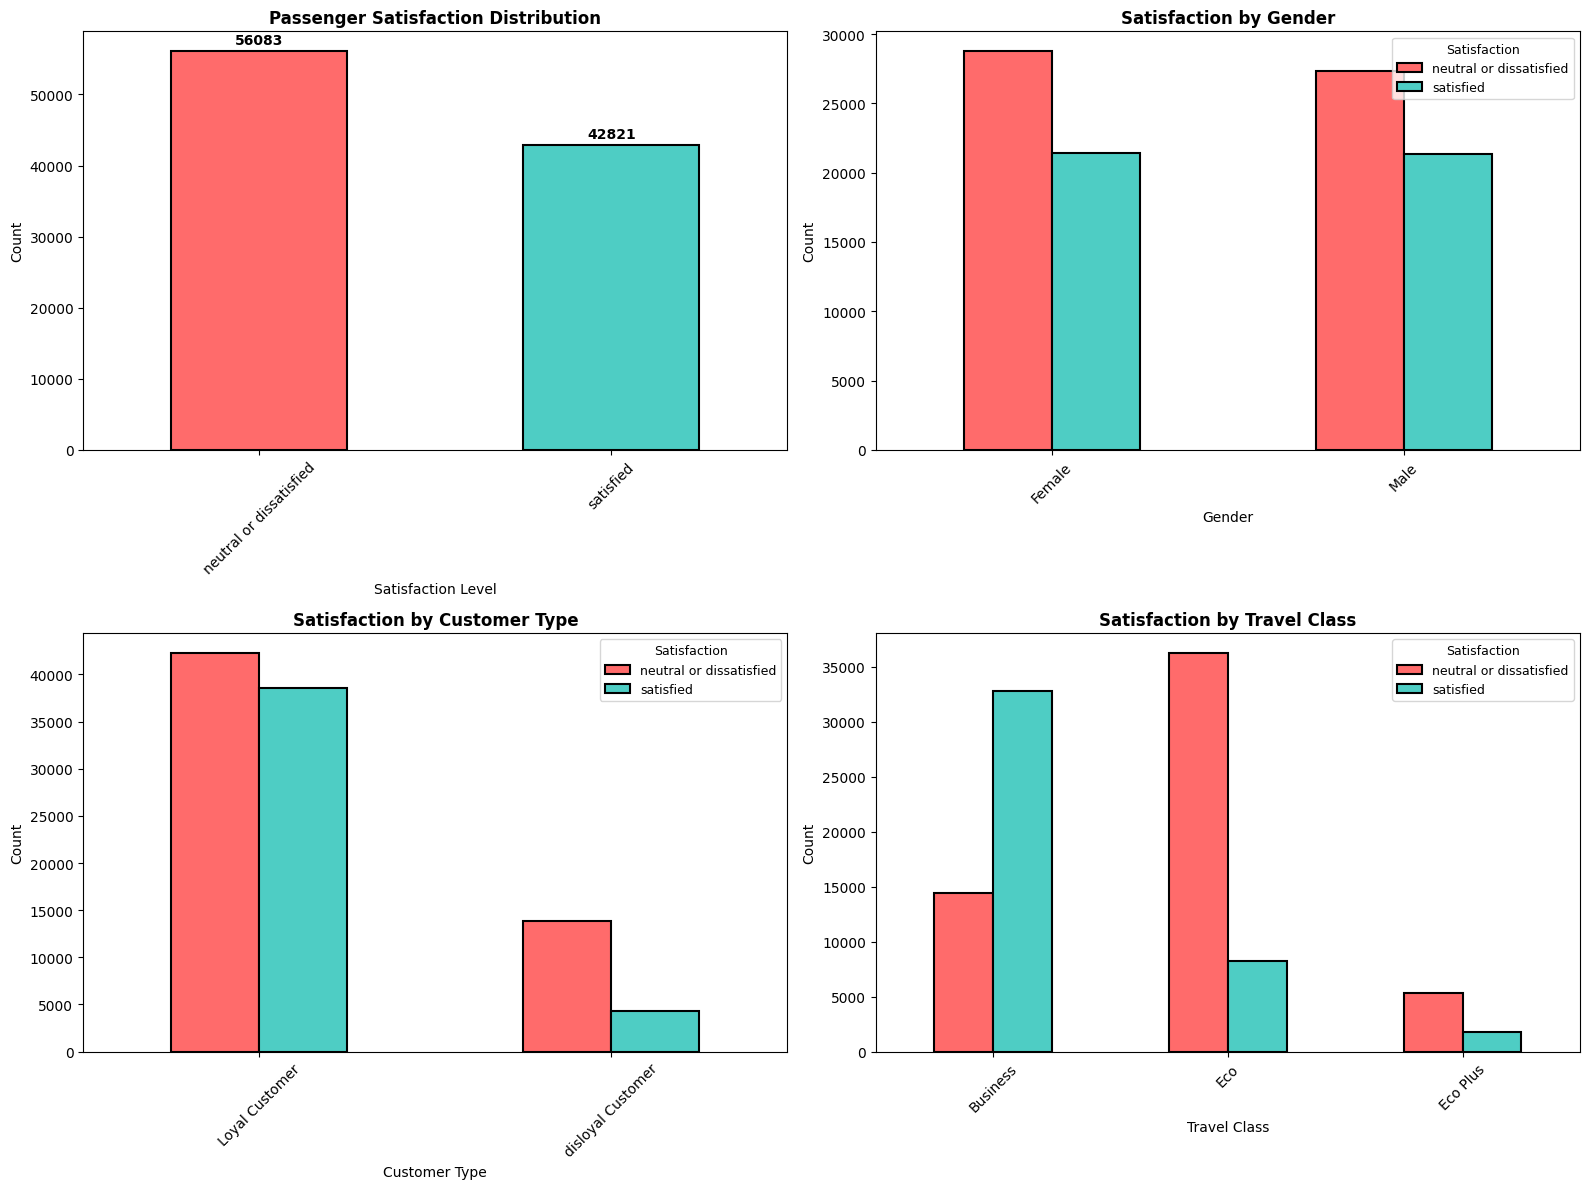

In [37]:
# MatplotlibVisualization 1: Satisfaction Relationships
print("\n" + "="*70)
print("MATPLOTLIB VISUALIZATION 1: SATISFACTION RELATIONSHIPS")
print("="*70 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1.1 Overall Satisfaction Distribution
satisfaction_counts = df['satisfaction'].value_counts()
ax1 = axes[0, 0]
satisfaction_counts.plot(kind='bar', ax=ax1, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=1.5)
ax1.set_title('Passenger Satisfaction Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Satisfaction Level', fontsize=10)
ax1.set_ylabel('Count', fontsize=10)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
for i, v in enumerate(satisfaction_counts.values):
    ax1.text(i, v + 1000, str(v), ha='center', fontweight='bold')

# 1.2 Satisfaction by Gender
ax2 = axes[0, 1]
cross_tab_gender = pd.crosstab(df['Gender'], df['satisfaction'])
cross_tab_gender.plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=1.5)
ax2.set_title('Satisfaction by Gender', fontsize=12, fontweight='bold')
ax2.set_xlabel('Gender', fontsize=10)
ax2.set_ylabel('Count', fontsize=10)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
ax2.legend(title='Satisfaction', title_fontsize=9, fontsize=9)

# 1.3 Satisfaction by Customer Type
ax3 = axes[1, 0]
cross_tab_ctype = pd.crosstab(df['Customer Type'], df['satisfaction'])
cross_tab_ctype.plot(kind='bar', ax=ax3, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=1.5)
ax3.set_title('Satisfaction by Customer Type', fontsize=12, fontweight='bold')
ax3.set_xlabel('Customer Type', fontsize=10)
ax3.set_ylabel('Count', fontsize=10)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)
ax3.legend(title='Satisfaction', title_fontsize=9, fontsize=9)

# 1.4 Satisfaction by Travel Class
ax4 = axes[1, 1]
cross_tab_class = pd.crosstab(df['Class'], df['satisfaction'])
cross_tab_class.plot(kind='bar', ax=ax4, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=1.5)
ax4.set_title('Satisfaction by Travel Class', fontsize=12, fontweight='bold')
ax4.set_xlabel('Travel Class', fontsize=10)
ax4.set_ylabel('Count', fontsize=10)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45)
ax4.legend(title='Satisfaction', title_fontsize=9, fontsize=9)

plt.tight_layout()
plt.savefig(f'{png_reports_dir}/viz_01_satisfaction_relationships.png', dpi=300, bbox_inches='tight')
plt.show()


MATPLOTLIB VISUALIZATION 2: CORRELATION MATRIX & HEATMAPS



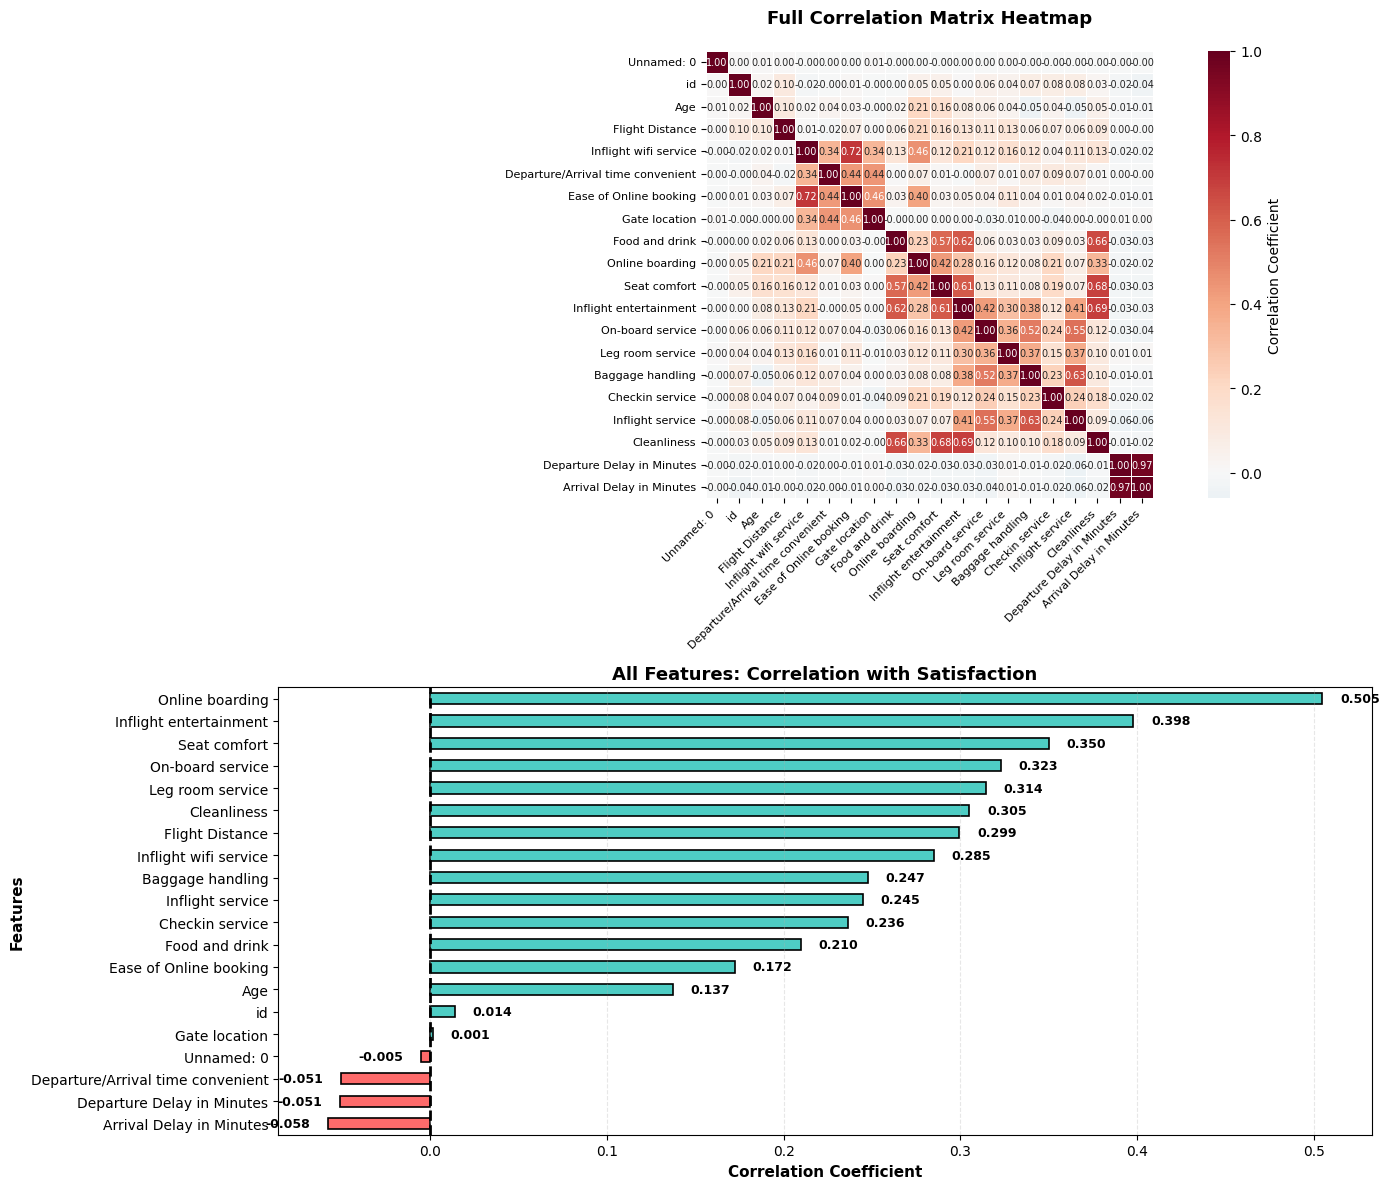

Top 10 Positive Correlations with Satisfaction:
Inflight service          0.244946
Baggage handling          0.247440
Inflight wifi service     0.285087
Flight Distance           0.299338
Cleanliness               0.305080
Leg room service          0.314162
On-board service          0.322706
Seat comfort              0.349950
Inflight entertainment    0.397715
Online boarding           0.504698

--------------------------------------------------
Features with Negative Correlation with Satisfaction:
Arrival Delay in Minutes            -0.057883
Departure Delay in Minutes          -0.050874
Departure/Arrival time convenient   -0.050670
Unnamed: 0                          -0.005404


In [38]:
# MatplotlibVisualization 2: Correlation Matrix and Heatmap
print("\n" + "="*70)
print("MATPLOTLIB VISUALIZATION 2: CORRELATION MATRIX & HEATMAPS")
print("="*70 + "\n")

# Create a figure with better sizing for correlation matrix
fig = plt.figure(figsize=(14, 12))

# Full Correlation Heatmap - larger and more readable
ax1 = plt.subplot(2, 1, 1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax1, 
            cbar_kws={'label': 'Correlation Coefficient'}, square=True, linewidths=0.5,
            annot_kws={'size': 7})
ax1.set_title('Full Correlation Matrix Heatmap', fontsize=13, fontweight='bold', pad=20)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontsize=8)

# Top Correlations with Satisfaction
ax2 = plt.subplot(2, 1, 2)
# Get top correlations with satisfaction
df_temp_corr = df.copy()
df_temp_corr['satisfaction_numeric'] = (df_temp_corr['satisfaction'] == 'satisfied').astype(int)
numeric_for_corr = df_temp_corr.select_dtypes(include=[np.number]).corr()['satisfaction_numeric'].drop('satisfaction_numeric').sort_values(ascending=True)

colors_corr = ['#FF6B6B' if x < 0 else '#4ECDC4' for x in numeric_for_corr]
numeric_for_corr.plot(kind='barh', ax=ax2, color=colors_corr, edgecolor='black', linewidth=1.2)
ax2.set_title('All Features: Correlation with Satisfaction', fontsize=13, fontweight='bold')
ax2.set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
ax2.set_ylabel('Features', fontsize=11, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (idx, v) in enumerate(numeric_for_corr.items()):
    ax2.text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', 
            va='center', ha='left' if v > 0 else 'right', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{png_reports_dir}/viz_02_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print correlation insights
print("Top 10 Positive Correlations with Satisfaction:")
print(numeric_for_corr.tail(10).to_string())
print("\n" + "-"*50)
print("Features with Negative Correlation with Satisfaction:")
print(numeric_for_corr[numeric_for_corr < 0].to_string())


MATPLOTLIB VISUALIZATION 3: SERVICE QUALITY ANALYSIS



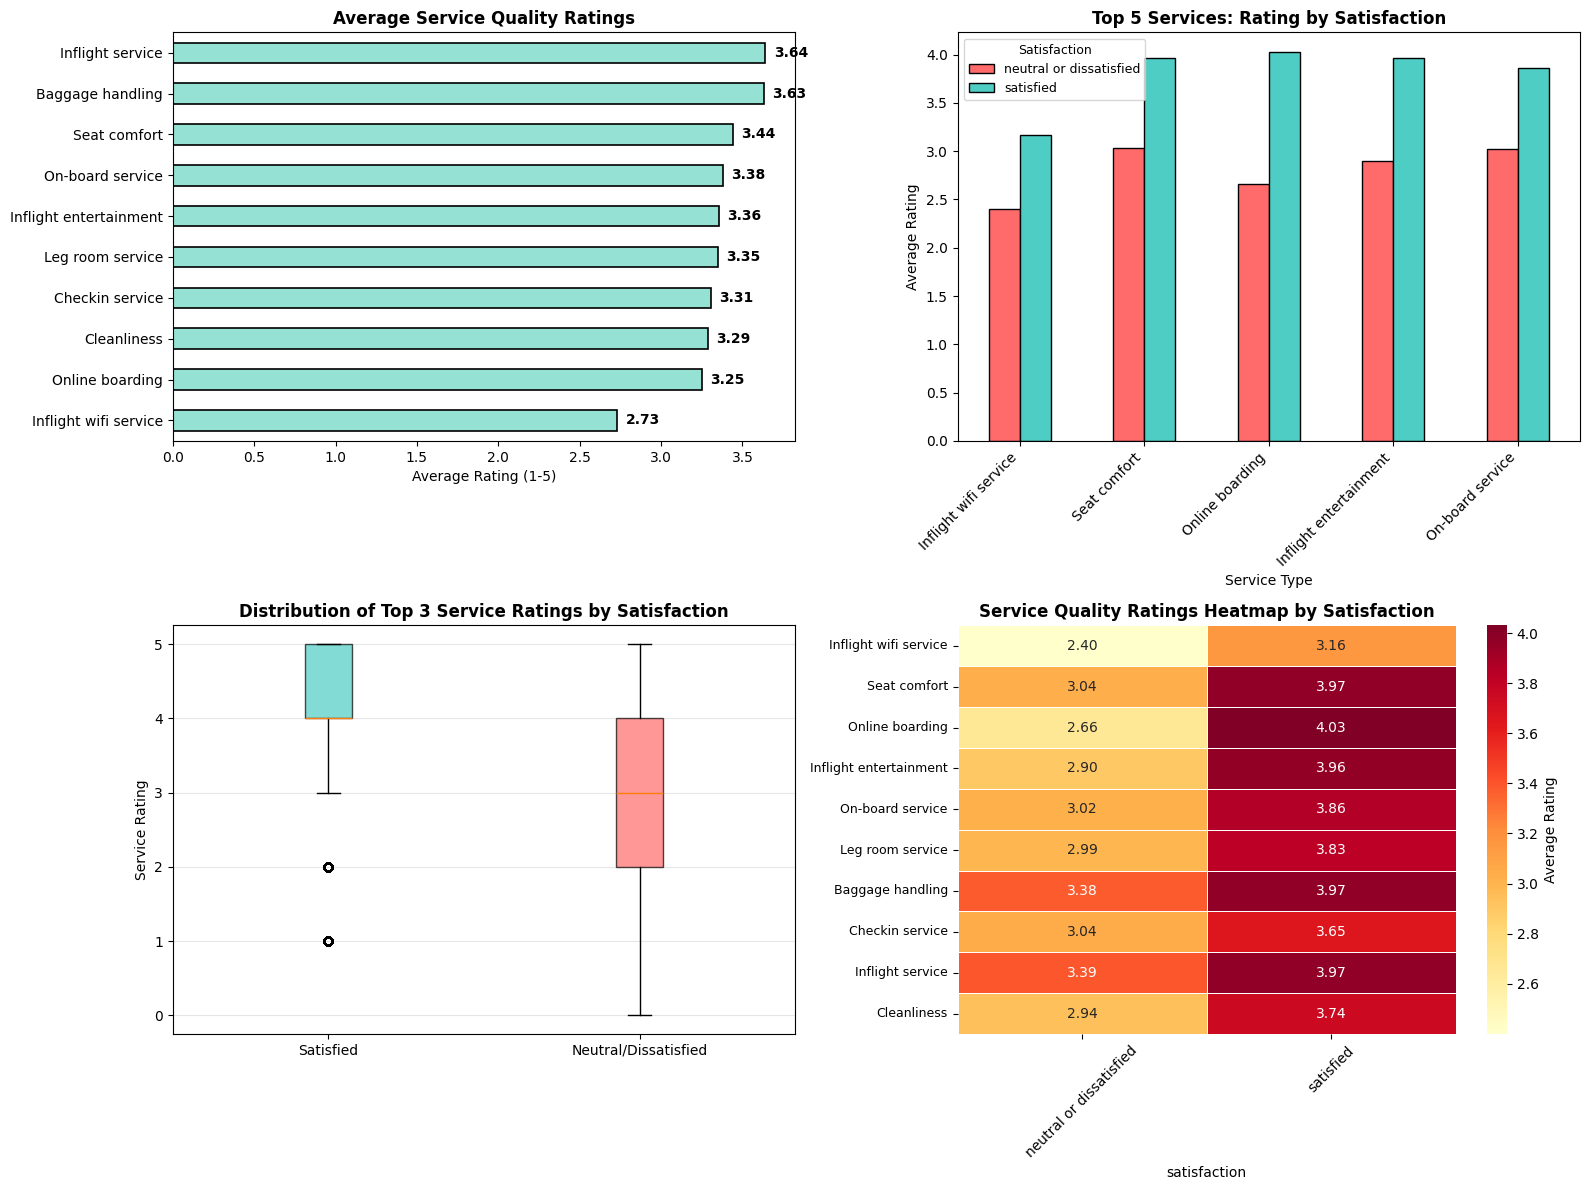

In [39]:
# MatplotlibVisualization 3: Service QualityAnalysis
print("\n" + "="*70)
print("MATPLOTLIB VISUALIZATION 3: SERVICE QUALITY ANALYSIS")
print("="*70 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3.1 Overall Service Quality Ratings
ax1 = axes[0, 0]
service_means_sorted = service_means.sort_values()
service_means_sorted.plot(kind='barh', ax=ax1, color='#95E1D3', edgecolor='black', linewidth=1.2)
ax1.set_title('Average Service Quality Ratings', fontsize=12, fontweight='bold')
ax1.set_xlabel('Average Rating (1-5)', fontsize=10)
for i, v in enumerate(service_means_sorted.values):
    ax1.text(v + 0.05, i, f'{v:.2f}', va='center', fontweight='bold')

# 3.2 Service Quality Comparison by Satisfaction
ax2 = axes[0, 1]
service_quality_comparison_data = df.groupby('satisfaction')[service_cols[:5]].mean()
service_quality_comparison_data.T.plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4'], 
                                        edgecolor='black', linewidth=1)
ax2.set_title('Top 5 Services: Rating by Satisfaction', fontsize=12, fontweight='bold')
ax2.set_xlabel('Service Type', fontsize=10)
ax2.set_ylabel('Average Rating', fontsize=10)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.legend(title='Satisfaction', title_fontsize=9, fontsize=9)

# 3.3 Box plot - Service ratings distribution by satisfaction (top 3 services)
ax3 = axes[1, 0]
top_3_services = service_means.nlargest(3).index.tolist()
data_for_box = [df[df['satisfaction'] == 'satisfied'][top_3_services].values.flatten(),
                df[df['satisfaction'] == 'neutral or dissatisfied'][top_3_services].values.flatten()]
bp = ax3.boxplot(data_for_box, labels=['Satisfied', 'Neutral/Dissatisfied'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#4ECDC4', '#FF6B6B']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_title(f'Distribution of Top 3 Service Ratings by Satisfaction', fontsize=12, fontweight='bold')
ax3.set_ylabel('Service Rating', fontsize=10)
ax3.grid(axis='y', alpha=0.3)

# 3.4 Heatmap - Service quality by satisfaction
ax4 = axes[1, 1]
service_heatmap_data = df.groupby('satisfaction')[service_cols].mean()
sns.heatmap(service_heatmap_data.T, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax4, 
            cbar_kws={'label': 'Average Rating'}, linewidths=0.5)
ax4.set_title('Service Quality Ratings Heatmap by Satisfaction', fontsize=12, fontweight='bold')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45)
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(f'{png_reports_dir}/viz_03_service_quality_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


MATPLOTLIB VISUALIZATION 4: STATISTICAL SUMMARIES & OUTLIER DETECTION



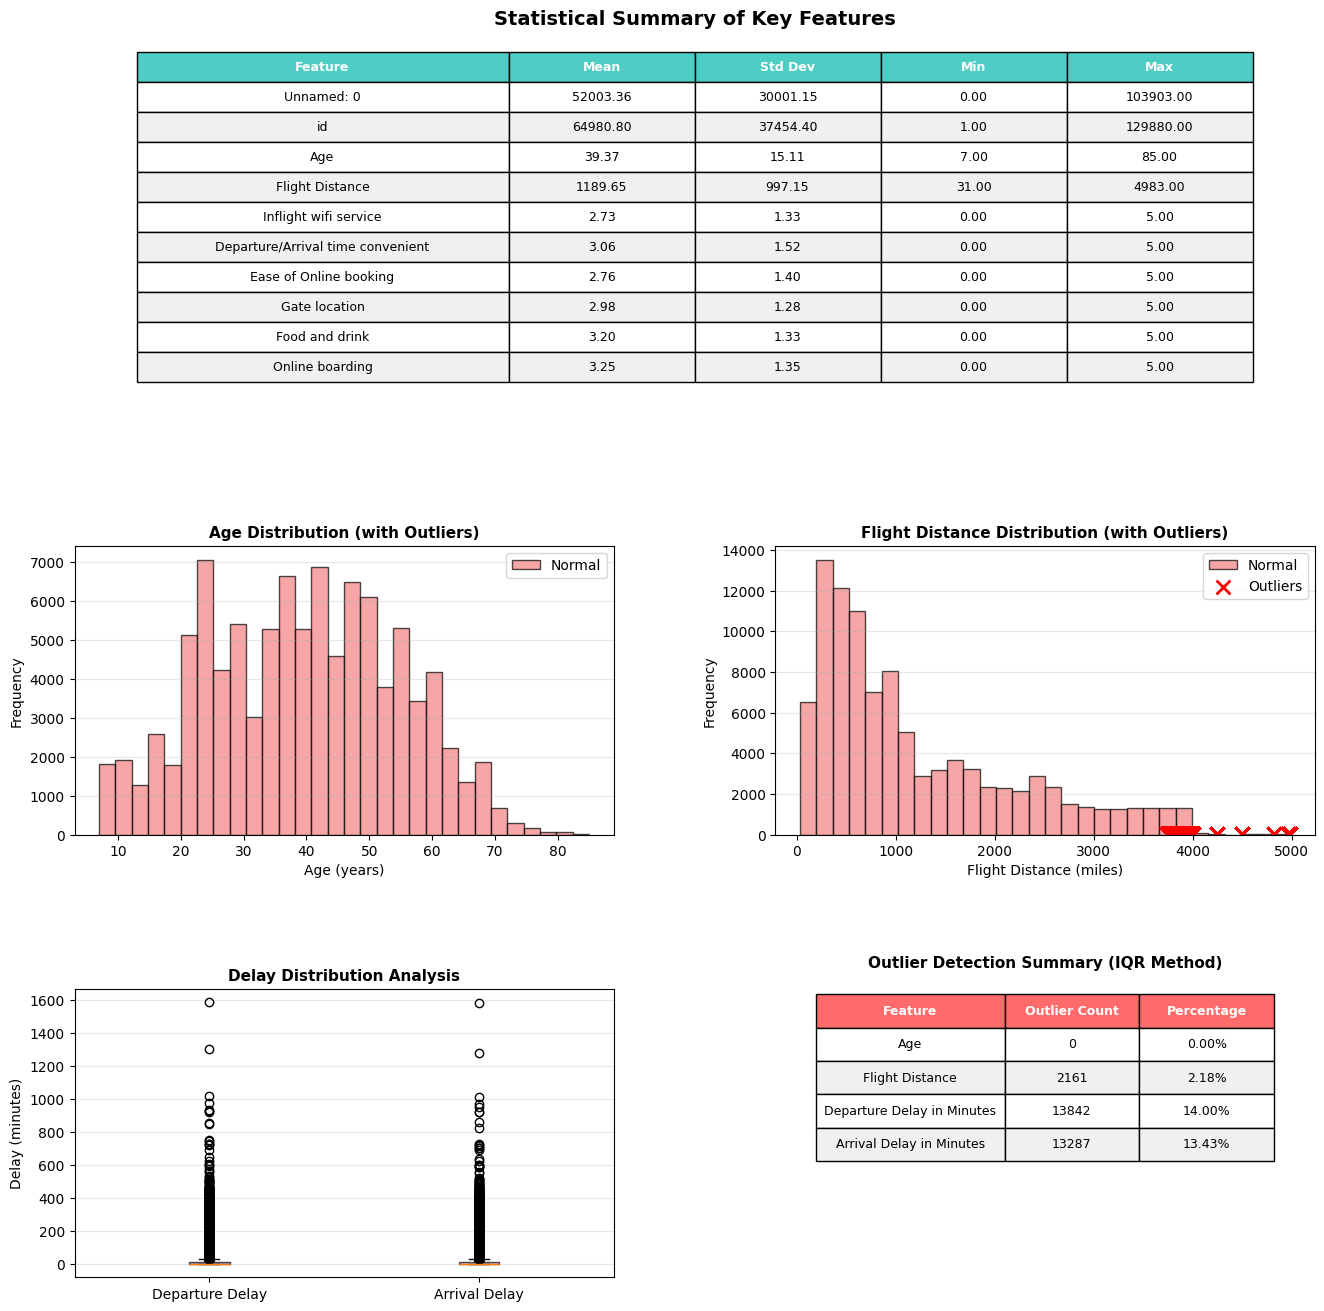

In [40]:
# MatplotlibVisualization 4: Statistical Summaries and Outlier Detection
print("\n" + "="*70)
print("MATPLOTLIB VISUALIZATION 4: STATISTICAL SUMMARIES & OUTLIER DETECTION")
print("="*70 + "\n")

fig = plt.figure(figsize=(16, 16))
gs = fig.add_gridspec(3, 2, hspace=0.5, wspace=0.3, height_ratios=[1.2, 1, 1])

# 4.1 Statistical Summary Table
ax1 = fig.add_subplot(gs[0, :])
ax1.axis('tight')
ax1.axis('off')
summary_display = summary_stats[['mean', 'std', 'min', 'max']].round(2)
table_data = []
for idx in summary_display.index[:10]:  # Show first 10 features
    row = [idx] + [f"{summary_display.loc[idx, col]:.2f}" for col in ['mean', 'std', 'min', 'max']]
    table_data.append(row)

table = ax1.table(cellText=table_data, colLabels=['Feature', 'Mean', 'Std Dev', 'Min', 'Max'],
                  cellLoc='center', loc='upper center', colWidths=[0.3, 0.15, 0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)
# Style header
for i in range(5):
    table[(0, i)].set_facecolor('#4ECDC4')
    table[(0, i)].set_text_props(weight='bold', color='white')
# Alternate row colors
for i in range(1, len(table_data) + 1):
    for j in range(5):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#F0F0F0')
        else:
            table[(i, j)].set_facecolor('white')
ax1.set_title('Statistical Summary of Key Features', fontsize=14, fontweight='bold', pad=15, loc='center')

# 4.2 Distribution of Age with outliers marked
ax2 = fig.add_subplot(gs[1, 0])
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age
outliers_age = df[(df['Age'] < lower_age) | (df['Age'] > upper_age)]['Age']
ax2.hist(df['Age'], bins=30, color='#F38181', edgecolor='black', alpha=0.7, label='Normal')
if len(outliers_age) > 0:
    ax2.scatter(outliers_age, [5]*len(outliers_age), color='red', s=100, marker='x', linewidths=2, label='Outliers')
ax2.set_title('Age Distribution (with Outliers)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Age (years)', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 4.3 Flight Distance distribution
ax3 = fig.add_subplot(gs[1, 1])
Q1_fd = df['Flight Distance'].quantile(0.25)
Q3_fd = df['Flight Distance'].quantile(0.75)
IQR_fd = Q3_fd - Q1_fd
lower_fd = Q1_fd - 1.5 * IQR_fd
upper_fd = Q3_fd + 1.5 * IQR_fd
outliers_fd = df[(df['Flight Distance'] < lower_fd) | (df['Flight Distance'] > upper_fd)]['Flight Distance']
ax3.hist(df['Flight Distance'], bins=30, color='#F38181', edgecolor='black', alpha=0.7, label='Normal')
if len(outliers_fd) > 0:
    ax3.scatter(outliers_fd, [5]*len(outliers_fd), color='red', s=100, marker='x', linewidths=2, label='Outliers')
ax3.set_title('Flight Distance Distribution (with Outliers)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Flight Distance (miles)', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4.4 Box plots for delay attributes
ax4 = fig.add_subplot(gs[2, 0])
delay_data = [df['Departure Delay in Minutes'].dropna(), df['Arrival Delay in Minutes'].dropna()]
bp = ax4.boxplot(delay_data, labels=['Departure Delay', 'Arrival Delay'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#AA96DA', '#FCBAD3']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_title('Delay Distribution Analysis', fontsize=11, fontweight='bold')
ax4.set_ylabel('Delay (minutes)', fontsize=10)
ax4.grid(axis='y', alpha=0.3)

# 4.5 Outlier Summary Table
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('tight')
ax5.axis('off')
outlier_summary = []
for col in ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_pct = (outlier_count / len(df)) * 100
        outlier_summary.append([col, str(outlier_count), f'{outlier_pct:.2f}%'])

table_outliers = ax5.table(cellText=outlier_summary, 
                          colLabels=['Feature', 'Outlier Count', 'Percentage'],
                          cellLoc='center', loc='upper center', colWidths=[0.35, 0.25, 0.25])
table_outliers.auto_set_font_size(False)
table_outliers.set_fontsize(9)
table_outliers.scale(1, 2)
# Style header
for i in range(3):
    table_outliers[(0, i)].set_facecolor('#FF6B6B')
    table_outliers[(0, i)].set_text_props(weight='bold', color='white')
# Alternate row colors
for i in range(1, len(outlier_summary) + 1):
    for j in range(3):
        if i % 2 == 0:
            table_outliers[(i, j)].set_facecolor('#F0F0F0')
        else:
            table_outliers[(i, j)].set_facecolor('white')
ax5.set_title('Outlier Detection Summary (IQR Method)', fontsize=11, fontweight='bold', pad=15)

plt.savefig(f'{png_reports_dir}/viz_04_statistical_summary_outliers.png', dpi=300, bbox_inches='tight')
plt.show()


MATPLOTLIB VISUALIZATION 5: NUMERICAL FEATURES VS SATISFACTION



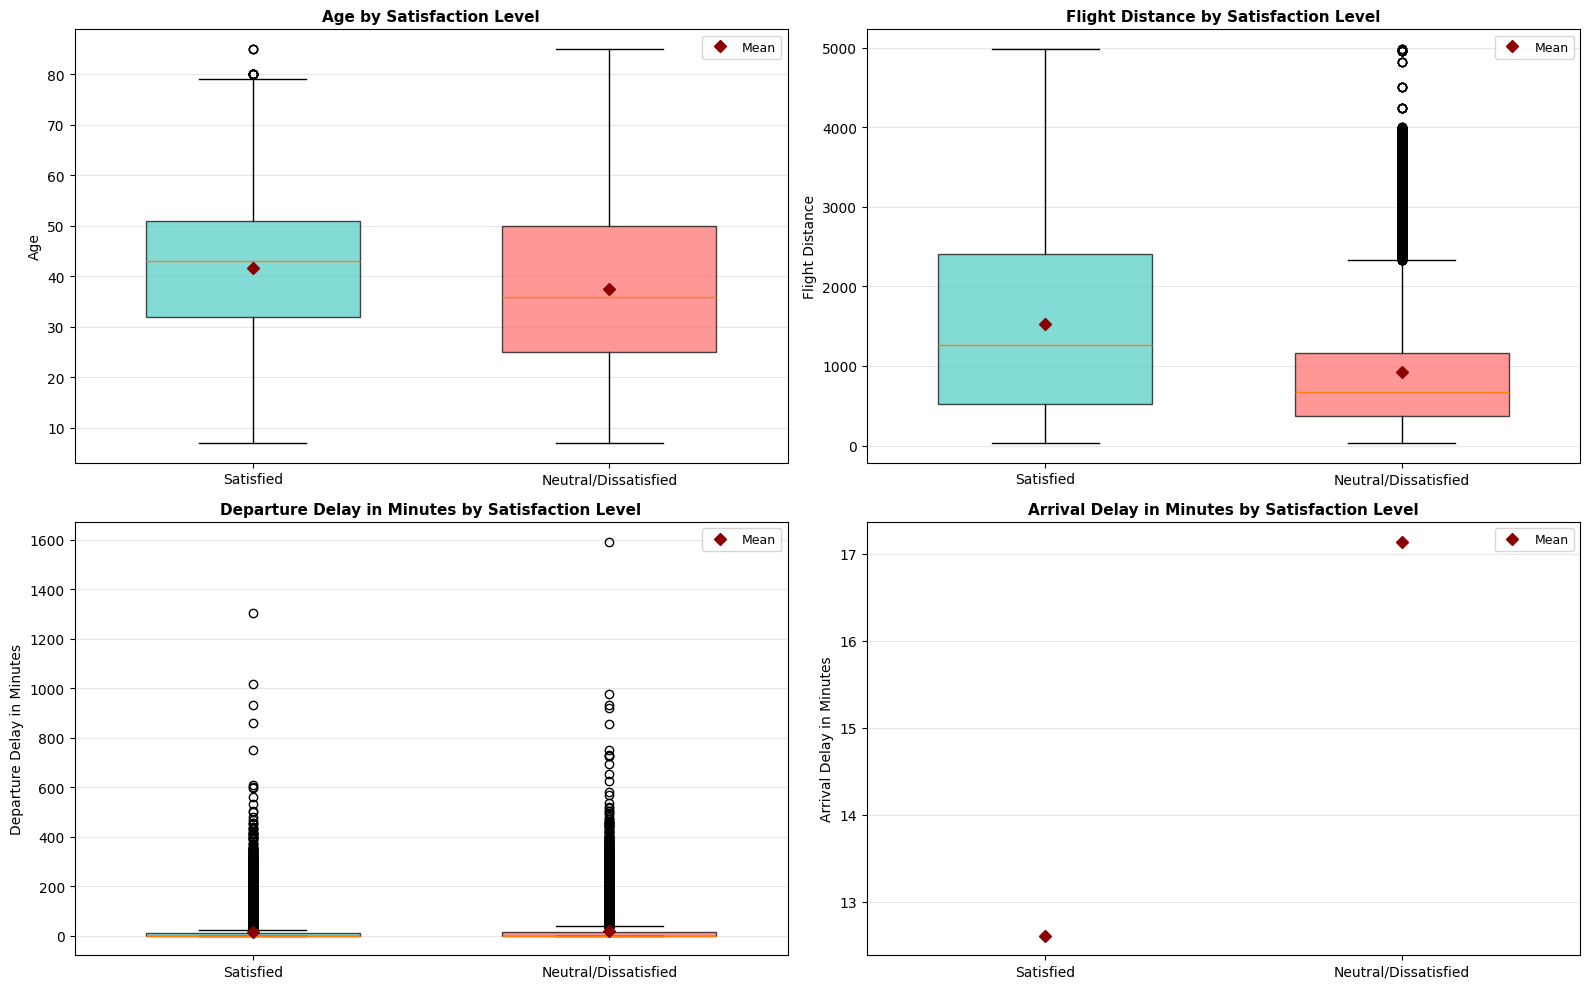

In [41]:
# MatplotlibVisualization 5: Numerical Features vs Satisfaction
print("\n" + "="*70)
print("MATPLOTLIB VISUALIZATION 5: NUMERICAL FEATURES VS SATISFACTION")
print("="*70 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, feature in enumerate(['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']):
    ax = axes[idx // 2, idx % 2]
    
    satisfied_data = df[df['satisfaction'] == 'satisfied'][feature]
    dissatisfied_data = df[df['satisfaction'] == 'neutral or dissatisfied'][feature]
    
    bp = ax.boxplot(
        [satisfied_data, dissatisfied_data],
        labels=['Satisfied', 'Neutral/Dissatisfied'],
        patch_artist=True,
        widths=0.6
    )
    
    for patch, color in zip(bp['boxes'], ['#4ECDC4', '#FF6B6B']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f'{feature} by Satisfaction Level', fontsize=11, fontweight='bold')
    ax.set_ylabel(feature, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean markers
    means = [satisfied_data.mean(), dissatisfied_data.mean()]
    ax.plot([1, 2], means, 'D', color='darkred', markersize=6, label='Mean', zorder=3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{png_reports_dir}/viz_05_numerical_vs_satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()


MATPLOTLIB VISUALIZATION 6: FEATURE IMPORTANCE & CLASS DISTRIBUTION



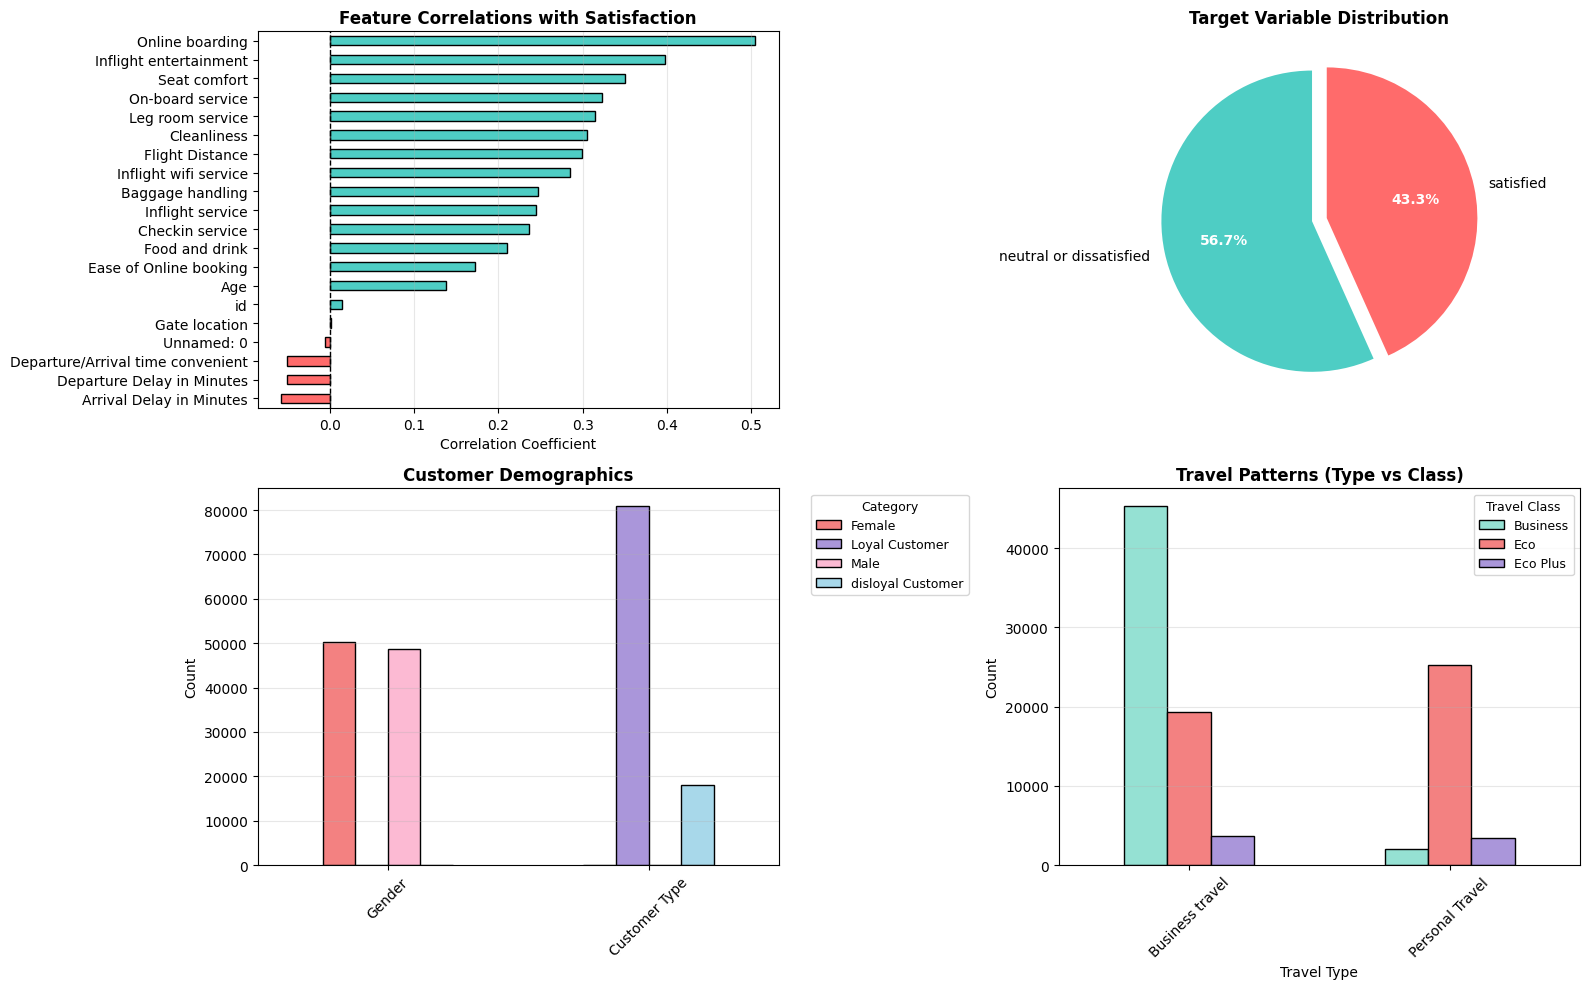

In [42]:
# MatplotlibVisualization 6: Feature Importance and Class Distribution Summary
print("\n" + "="*70)
print("MATPLOTLIB VISUALIZATION 6: FEATURE IMPORTANCE & CLASS DISTRIBUTION")
print("="*70 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 6.1 Top 15 Features by Correlation with Satisfaction
ax1 = axes[0, 0]
all_corr = numeric_for_corr if 'numeric_for_corr' in locals() else df.corr()['satisfaction' if 'satisfaction' in df.columns else 'satisfaction_numeric']
top_corr = all_corr.sort_values(ascending=True)
colors_imp = ['#FF6B6B' if x < 0 else '#4ECDC4' for x in top_corr.values]
top_corr.plot(kind='barh', ax=ax1, color=colors_imp, edgecolor='black', linewidth=1)
ax1.set_title('Feature Correlations with Satisfaction', fontsize=12, fontweight='bold')
ax1.set_xlabel('Correlation Coefficient', fontsize=10)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.grid(axis='x', alpha=0.3)

# 6.2 Class Distribution (Pie chart)
ax2 = axes[0, 1]
satisfaction_counts_for_pie = df['satisfaction'].value_counts()
colors_pie = ['#4ECDC4', '#FF6B6B']
wedges, texts, autotexts = ax2.pie(satisfaction_counts_for_pie.values, 
                                     labels=satisfaction_counts_for_pie.index,
                                     autopct='%1.1f%%', colors=colors_pie, 
                                     startangle=90, explode=(0.05, 0.05))
ax2.set_title('Target Variable Distribution', fontsize=12, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# 6.3 Customer Demographics
ax3 = axes[1, 0]
demo_data = pd.DataFrame({
    'Gender': df['Gender'].value_counts(),
    'Customer Type': df['Customer Type'].value_counts()
})
demo_data.T.plot(kind='bar', ax=ax3, edgecolor='black', linewidth=1, 
                 color=['#F38181', '#AA96DA', '#FCBAD3', '#A8D8EA'])
ax3.set_title('Customer Demographics', fontsize=12, fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Count', fontsize=10)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)
ax3.legend(title='Category', title_fontsize=9, fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(axis='y', alpha=0.3)

# 6.4 Travel Patterns
ax4 = axes[1, 1]
travel_data = df[['Type of Travel', 'Class']].value_counts().unstack(fill_value=0)
travel_data.plot(kind='bar', ax=ax4, edgecolor='black', linewidth=1,
                 color=['#95E1D3', '#F38181', '#AA96DA'])
ax4.set_title('Travel Patterns (Type vs Class)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Travel Type', fontsize=10)
ax4.set_ylabel('Count', fontsize=10)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45)
ax4.legend(title='Travel Class', title_fontsize=9, fontsize=9)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{png_reports_dir}/viz_06_feature_importance_summary.png', dpi=300, bbox_inches='tight')
plt.show()